# End-to-End Test

## Import Functions to Test

In [1]:
from raag_midi_gen.model.components.embedding_layer import NoteEventEmbedding

## Import Helper Functions

In [2]:
from raag_midi_gen.tokenizer import encode_input
from raag_midi_gen.datasets import midi_files_dataset

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Get Data Sample

In [4]:
# test_clip_filename = 'Taraana - Antra 2.0.mid'        # EASY
test_clip_filename = 'Aeri Aali - Sthaayi 1.1_2.mid'  # HARD

In [5]:
dataset = midi_files_dataset.get_dataset()
sample_midi = dataset[test_clip_filename][-1]

## Encode Input

In [6]:
input_encoding = encode_input(sample_midi)

## Compute Embedding

In [7]:
embedding_layer = NoteEventEmbedding()
output_embedding = embedding_layer(input_encoding)

## Inspect Output Embedding

In [8]:
output_embedding.shape

torch.Size([768, 16])

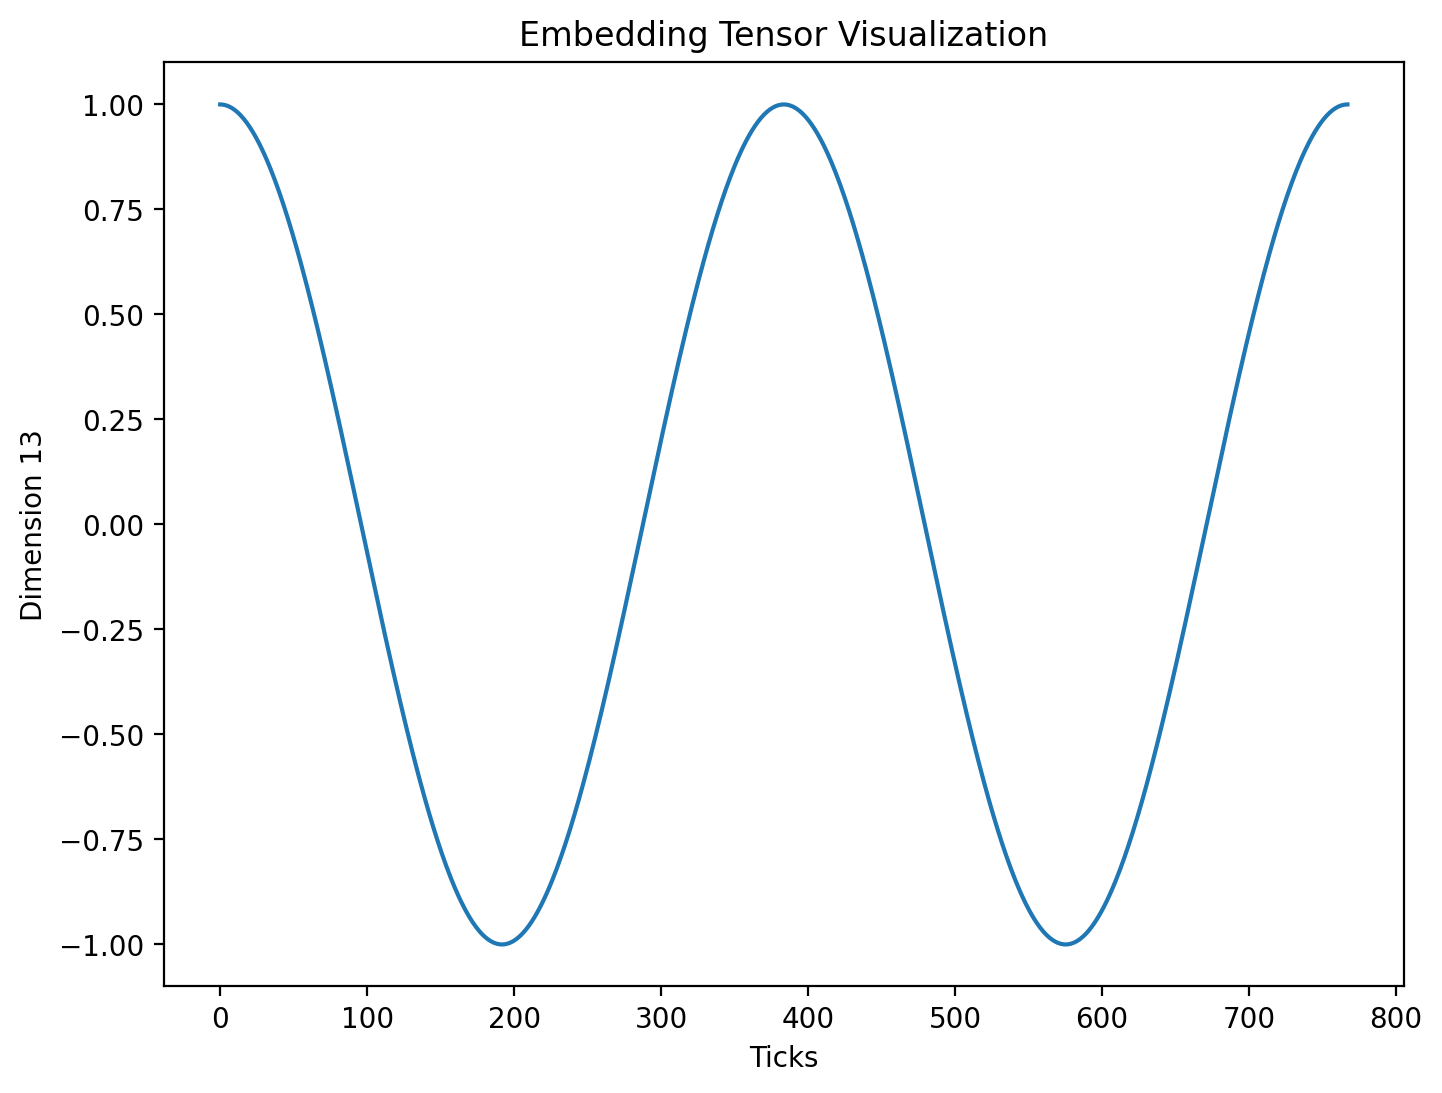

In [21]:
numpy_tensor = output_embedding.detach().cpu().numpy()

dimension_to_plot = 13

plt.figure(figsize=(8, 6))
sns.lineplot(numpy_tensor[:,dimension_to_plot])
plt.title(f'Embedding Tensor Visualization')
plt.xlabel('Ticks')
plt.ylabel(f'Dimension {dimension_to_plot}')
plt.show()